In [238]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [239]:
df=pd.read_csv('dataset/processed/train.csv')
df.head()

,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Datetime
0,"""CNR4352144""",Completed,"""CID8362794""",Bike,Udyog Vihar,Ambience Mall,10.8,38.9,NaN,NaN,NaN,NaN,NaN,NaN,99.0,37.98,4.8,4.8,Cash,2024-01-01 00:19:34
1,"""CNR9147645""",Completed,"""CID8300238""",Go Mini,Basai Dhankot,Madipur,8.5,15.1,NaN,NaN,NaN,NaN,NaN,NaN,114.0,39.29,4.2,4.1,Uber Wallet,2024-01-01 01:35:18
2,"""CNR1009222""",Cancelled by Driver,"""CID2030746""",Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,NaN,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:37:50
3,"""CNR2740479""",Cancelled by Driver,"""CID3231181""",Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,NaN,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:48:03
4,"""CNR7650148""",Cancelled by Driver,"""CID3381661""",Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,NaN,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-01 01:49:56


In [240]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Booking ID                         100000 non-null  str    
 1   Booking Status                     100000 non-null  str    
 2   Customer ID                        100000 non-null  str    
 3   Vehicle Type                       100000 non-null  str    
 4   Pickup Location                    100000 non-null  str    
 5   Drop Location                      100000 non-null  str    
 6   Avg VTAT                           92999 non-null   float64
 7   Avg CTAT                           67943 non-null   float64
 8   Cancelled Rides by Customer        6955 non-null    float64
 9   Reason for cancelling by Customer  6955 non-null    str    
 10  Cancelled Rides by Driver          18101 non-null   float64
 11  Driver Cancellation Reason         18101 non-null  

In [241]:
# Converting Datetime to datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])

cols = ['Datetime'] + [col for col in df.columns if col != 'Datetime']
df = df[cols]
df.sample(5)

,Datetime,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
64813,2024-06-06 15:23:56,"""CNR2588947""",Completed,"""CID8379692""",Go Mini,Tis Hazari,Keshav Puram,14.7,24.7,NaN,NaN,NaN,NaN,NaN,NaN,341.0,37.90,4.6,4.2,Uber Wallet
63355,2024-06-03 02:11:27,"""CNR2480314""",Completed,"""CID6056932""",Go Mini,Vaishali,Khan Market,2.3,42.0,NaN,NaN,NaN,NaN,NaN,NaN,75.0,28.64,4.2,4.6,Uber Wallet
28892,2024-03-11 07:50:38,"""CNR4041781""",Completed,"""CID9941467""",Auto,Preet Vihar,Nirman Vihar,4.5,45.0,NaN,NaN,NaN,NaN,NaN,NaN,560.0,16.71,4.3,4.3,Credit Card
20639,2024-02-19 20:14:28,"""CNR2284406""",Completed,"""CID8600554""",Auto,Indraprastha,ITO,3.3,22.1,NaN,NaN,NaN,NaN,NaN,NaN,237.0,35.07,4.2,4.6,UPI
36074,2024-03-28 15:41:41,"""CNR6121429""",Completed,"""CID5919599""",Bike,IIT Delhi,Qutub Minar,7.7,30.1,NaN,NaN,NaN,NaN,NaN,NaN,192.0,30.51,3.8,4.5,Cash


In [242]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Datetime                           100000 non-null  datetime64[us]
 1   Booking ID                         100000 non-null  str           
 2   Booking Status                     100000 non-null  str           
 3   Customer ID                        100000 non-null  str           
 4   Vehicle Type                       100000 non-null  str           
 5   Pickup Location                    100000 non-null  str           
 6   Drop Location                      100000 non-null  str           
 7   Avg VTAT                           92999 non-null   float64       
 8   Avg CTAT                           67943 non-null   float64       
 9   Cancelled Rides by Customer        6955 non-null    float64       
 10  Reason for cancelling by Custome

### **Selection of features for the driver acceptance model**

In [243]:
features = [
    'Datetime',
    'Vehicle Type',
    'Pickup Location',
    'Drop Location',
    'Booking Value',
]

In [244]:
df=df[features + ['Booking Status']]
df.head()

,Datetime,Vehicle Type,Pickup Location,Drop Location,Booking Value,Booking Status
0,2024-01-01 00:19:34,Bike,Udyog Vihar,Ambience Mall,99.0,Completed
1,2024-01-01 01:35:18,Go Mini,Basai Dhankot,Madipur,114.0,Completed
2,2024-01-01 01:37:50,Go Sedan,Tughlakabad,Greater Kailash,NaN,Cancelled by Driver
3,2024-01-01 01:48:03,Auto,Palam Vihar,Kherki Daula Toll,NaN,Cancelled by Driver
4,2024-01-01 01:49:56,Go Sedan,Narsinghpur,Pulbangash,NaN,Cancelled by Driver


In [245]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Datetime         100000 non-null  datetime64[us]
 1   Vehicle Type     100000 non-null  str           
 2   Pickup Location  100000 non-null  str           
 3   Drop Location    100000 non-null  str           
 4   Booking Value    67943 non-null   float64       
 5   Booking Status   100000 non-null  str           
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 4.6 MB


In [246]:
df["Booking Status"].value_counts()

Booking Status
Completed                61982
Cancelled by Driver      18101
No Driver Found           7001
Cancelled by Customer     6955
Incomplete                5961
Name: count, dtype: int64

### Converting Booking Status to driver acceptance (0 or 1) 

- 0 - No Driver Found (no driver accepted the request)
- 1 - Completed, Cancelled by Driver (driver accepted the request at some point)

In [247]:
df = df[~df['Booking Status'].isin([
    'Cancelled by Customer',
    'Incomplete'
])]

df['driver_acceptance'] = df['Booking Status'].apply(
    lambda x: 0 if x == 'No Driver Found' else 1
)

df.drop(columns=['Booking Status'], inplace=True)

df.sample(5)

,Datetime,Vehicle Type,Pickup Location,Drop Location,Booking Value,driver_acceptance
25895,2024-03-03 18:56:53,Premier Sedan,Okhla,Mundka,435.0,1
79766,2024-07-12 13:56:22,Go Sedan,Badshahpur,Green Park,697.0,1
14929,2024-02-05 20:43:39,Auto,Jhilmil,Vatika Chowk,771.0,1
29974,2024-03-13 17:36:00,Auto,Uttam Nagar,Rohini,184.0,1
17355,2024-02-11 18:40:18,Go Mini,Uttam Nagar,Mansarovar Park,792.0,1


In [248]:
df.info()

<class 'pandas.DataFrame'>
Index: 87084 entries, 0 to 99998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Datetime           87084 non-null  datetime64[us]
 1   Vehicle Type       87084 non-null  str           
 2   Pickup Location    87084 non-null  str           
 3   Drop Location      87084 non-null  str           
 4   Booking Value      61982 non-null  float64       
 5   driver_acceptance  87084 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 4.7 MB


In [249]:
df['driver_acceptance'].value_counts()

driver_acceptance
1    80083
0     7001
Name: count, dtype: int64

- Data is unbalanced with 92% of the data being 1 (accepted) and 8% being 0 (not accepted).

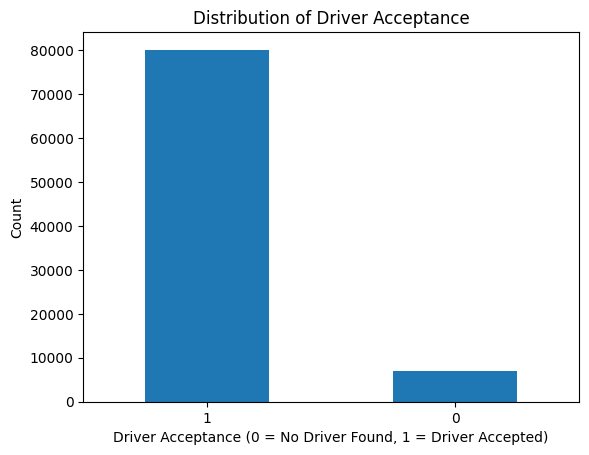

In [250]:
df['driver_acceptance'].value_counts().plot(kind='bar')
plt.title('Distribution of Driver Acceptance')
plt.xlabel('Driver Acceptance (0 = No Driver Found, 1 = Driver Accepted)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### **Feature Engineering**

In [251]:
df.info()

<class 'pandas.DataFrame'>
Index: 87084 entries, 0 to 99998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Datetime           87084 non-null  datetime64[us]
 1   Vehicle Type       87084 non-null  str           
 2   Pickup Location    87084 non-null  str           
 3   Drop Location      87084 non-null  str           
 4   Booking Value      61982 non-null  float64       
 5   driver_acceptance  87084 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 4.7 MB


In [252]:
# Time features
df['day_of_week'] = df['Datetime'].dt.dayofweek
df['month'] = df['Datetime'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df["is_peak_hour"] = df['Datetime'].dt.hour.apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)
df.drop(columns=['Datetime'], inplace=True)
df.head()

,Vehicle Type,Pickup Location,Drop Location,Booking Value,driver_acceptance,day_of_week,month,is_weekend,is_peak_hour
0,Bike,Udyog Vihar,Ambience Mall,99.0,1,0,1,0,0
1,Go Mini,Basai Dhankot,Madipur,114.0,1,0,1,0,0
2,Go Sedan,Tughlakabad,Greater Kailash,NaN,1,0,1,0,0
3,Auto,Palam Vihar,Kherki Daula Toll,NaN,1,0,1,0,0
4,Go Sedan,Narsinghpur,Pulbangash,NaN,1,0,1,0,0


In [253]:
df['Vehicle Type'].value_counts()

Vehicle Type
Auto             21629
Go Mini          17127
Go Sedan         15813
Bike             13202
Premier Sedan    10592
eBike             6162
Uber XL           2559
Name: count, dtype: int64

In [254]:
# Label encoding for categorical features

from sklearn.preprocessing import OrdinalEncoder

# Define order (low → high prices)
vehicle_price_order = [
    ['eBike', 'Bike', 'Auto', 'Go Mini', 'Go Sedan', 'Premier Sedan', 'Uber XL']
]

encoder = OrdinalEncoder(categories=vehicle_price_order)

df[['Vehicle Type']] = encoder.fit_transform(df[['Vehicle Type']])
df.head()

,Vehicle Type,Pickup Location,Drop Location,Booking Value,driver_acceptance,day_of_week,month,is_weekend,is_peak_hour
0,1.0,Udyog Vihar,Ambience Mall,99.0,1,0,1,0,0
1,3.0,Basai Dhankot,Madipur,114.0,1,0,1,0,0
2,4.0,Tughlakabad,Greater Kailash,NaN,1,0,1,0,0
3,2.0,Palam Vihar,Kherki Daula Toll,NaN,1,0,1,0,0
4,4.0,Narsinghpur,Pulbangash,NaN,1,0,1,0,0


### **Handling Missing Values**

<Axes: xlabel='Booking Value', ylabel='Count'>

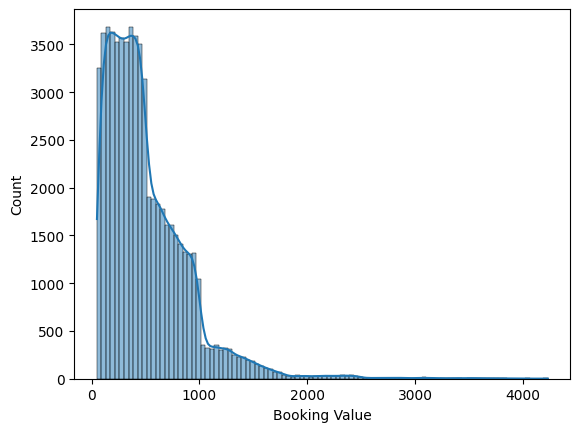

In [255]:
sns.histplot(df['Booking Value'], bins=100, kde=True)

In [256]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['driver_acceptance'])

In [257]:
train_df['Drop Location'].value_counts()

Drop Location
Dilshad Garden      455
Narsinghpur         439
Lok Kalyan Marg     437
Shastri Nagar       436
Udyog Vihar         434
                   ... 
Hauz Rani           353
Okhla               352
Malviya Nagar       350
Pragati Maidan      344
Huda City Centre    341
Name: count, Length: 176, dtype: int64

In [258]:
train_df['route'] = train_df['Pickup Location'] + "_" + train_df['Drop Location']
test_df['route']  = test_df['Pickup Location'] + "_" + test_df['Drop Location']
train_df.head()

,Vehicle Type,Pickup Location,Drop Location,Booking Value,driver_acceptance,day_of_week,month,is_weekend,is_peak_hour,route
58412,3.0,Moolchand,Paschim Vihar,NaN,1,1,5,0,0,Moolchand_Paschim Vihar
29466,1.0,Punjabi Bagh,Rajiv Chowk,NaN,1,1,3,0,0,Punjabi Bagh_Rajiv Chowk
87665,2.0,Panipat,Shastri Nagar,326.0,1,2,7,0,1,Panipat_Shastri Nagar
46982,2.0,New Delhi Railway Station,Ramesh Nagar,382.0,1,2,4,0,1,New Delhi Railway Station_Ramesh Nagar
22139,4.0,Welcome,Shastri Nagar,137.0,1,4,2,0,0,Welcome_Shastri Nagar


In [259]:
# Route + Vehicle median
rv_median = train_df.groupby(
    ['Vehicle Type', 'Pickup Location', 'Drop Location']
)['Booking Value'].median()
print(f"Route + Vehicle median: {rv_median}")

# Vehicle median
v_median = train_df.groupby('Vehicle Type')['Booking Value'].median()
print(f"Vehicle median: {v_median}") 

# Global median
g_median = train_df['Booking Value'].median()
print(f"Global median: {g_median}")

Route + Vehicle median: Vehicle Type  Pickup Location  Drop Location
0.0           AIIMS            Ashok Vihar      766.0
                               Aya Nagar          NaN
                               Bahadurgarh      679.0
                               Basai Dhankot    407.0
                               Ghaziabad          NaN
                                                ...  
6.0           Yamuna Bank      IIT Delhi        416.0
                               Khan Market      192.0
                               Punjabi Bagh     381.0
                               Seelampur         83.0
                               Sushant Lok        NaN
Name: Booking Value, Length: 57575, dtype: float64
Vehicle median: Vehicle Type
0.0    414.0
1.0    410.0
2.0    414.0
3.0    406.0
4.0    416.0
5.0    422.0
6.0    411.0
Name: Booking Value, dtype: float64
Global median: 413.0


In [260]:
# train_df['was_missing'] = train_df['Booking Value'].isnull().astype(int)
# test_df['was_missing']  = test_df['Booking Value'].isnull().astype(int)

In [261]:
# Create route first
train_df['route'] = train_df['Pickup Location'] + "_" + train_df['Drop Location']

# Route mean (for step 2)
route_mean = train_df.groupby('route')['Booking Value'].mean()

# Vehicle median (already used later)
v_median = train_df.groupby('Vehicle Type')['Booking Value'].median()

# Global median (for scaling)
global_median = train_df['Booking Value'].median()

# Vehicle scale (IMPORTANT)
vehicle_scale = v_median / global_median

In [262]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class BookingValueImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.rv_median = None
        self.route_mean = None
        self.vehicle_scale = None
        self.v_median = None
        self.global_mean = None

    def fit(self, X, y=None):
        X = X.copy()

        # Create route
        X['route'] = X['Pickup Location'] + "_" + X['Drop Location']

        # Store global mean (final fallback)
        self.global_mean = X['Booking Value'].mean()

        # Route + Vehicle median
        self.rv_median = X.groupby(
            ['Vehicle Type', 'Pickup Location', 'Drop Location']
        )['Booking Value'].median()

        # Route mean
        self.route_mean = X.groupby('route')['Booking Value'].mean()

        # Vehicle median
        self.v_median = X.groupby('Vehicle Type')['Booking Value'].median()

        # Vehicle scale
        self.vehicle_scale = self.v_median / self.global_mean

        return self

    def transform(self, X):
        X = X.copy()
        print("Number of missing values before imputation:", X['Booking Value'].isnull().sum())
        print(f"Statistics of 'Booking Value' before imputation:\n{X['Booking Value'].describe()}")

        # Create route
        X['route'] = X['Pickup Location'] + "_" + X['Drop Location']

        # Merge mappings
        X = X.merge(self.rv_median.rename('rv_median'),
                    on=['Vehicle Type', 'Pickup Location', 'Drop Location'],
                    how='left')

        X = X.merge(self.route_mean.rename('route_mean'),
                    on='route',
                    how='left')

        X = X.merge(self.vehicle_scale.rename('vehicle_scale'),
                    on='Vehicle Type',
                    how='left')

        X = X.merge(self.v_median.rename('v_median'),
                    on='Vehicle Type',
                    how='left')

        # Step 1
        X['Booking Value'] = X['Booking Value'].fillna(X['rv_median'])
        print("Number of missing values after vehicle + route imputation:", X['Booking Value'].isnull().sum())
        print(f"Statistics of 'Booking Value' after vehicle + route imputation:\n{X['Booking Value'].describe()}")

        # Step 2
        X['scaled_route_price'] = X['route_mean'] * X['vehicle_scale']
        X['Booking Value'] = X['Booking Value'].fillna(X['scaled_route_price'])
        print("Number of missing values after scaled route price imputation:", X['Booking Value'].isnull().sum())
        print(f"Statistics of 'Booking Value' after scaled route price imputation:\n{X['Booking Value'].describe()}")

        # Step 3
        X['Booking Value'] = X['Booking Value'].fillna(X['v_median'])
        print("Number of missing values after vehicle median imputation:", X['Booking Value'].isnull().sum())
        print(f"Statistics of 'Booking Value' after vehicle median imputation:\n{X['Booking Value'].describe()}")

        # Final fallback 
        X['Booking Value'] = X['Booking Value'].fillna(self.global_mean)
        print("Number of missing values after global mean imputation:", X['Booking Value'].isnull().sum())
        print(f"Statistics of 'Booking Value' after global mean imputation:\n{X['Booking Value'].describe()}")

        # Cleanup
        X.drop(columns=[
            'rv_median', 'route_mean', 'vehicle_scale',
            'v_median', 'scaled_route_price', 'route'
        ], inplace=True)

        return X

In [263]:
imputer = BookingValueImputer()

# Fit ONLY on train
train_df = imputer.fit_transform(train_df)

# Apply SAME learned stats on test
test_df = imputer.transform(test_df)

Number of missing values before imputation: 20034
Statistics of 'Booking Value' before imputation:
count    49633.000000
mean       505.200431
std        391.437300
min         50.000000
25%        233.000000
50%        413.000000
75%        684.000000
max       4228.000000
Name: Booking Value, dtype: float64
Number of missing values after vehicle + route imputation: 15053
Statistics of 'Booking Value' after vehicle + route imputation:
count    54614.000000
mean       504.896126
std        389.777392
min         50.000000
25%        234.000000
50%        413.000000
75%        682.000000
max       4228.000000
Name: Booking Value, dtype: float64
Number of missing values after scaled route price imputation: 4052
Statistics of 'Booking Value' after scaled route price imputation:
count    65615.000000
mean       489.405009
std        373.258788
min         40.182072
25%        235.000000
50%        402.000000
75%        649.000000
max       4228.000000
Name: Booking Value, dtype: float64
Nu

In [264]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69667 entries, 0 to 69666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Vehicle Type       69667 non-null  float64
 1   Pickup Location    69667 non-null  str    
 2   Drop Location      69667 non-null  str    
 3   Booking Value      69667 non-null  float64
 4   driver_acceptance  69667 non-null  int64  
 5   day_of_week        69667 non-null  int32  
 6   month              69667 non-null  int32  
 7   is_weekend         69667 non-null  int64  
 8   is_peak_hour       69667 non-null  int64  
dtypes: float64(2), int32(2), int64(3), str(2)
memory usage: 4.3 MB


In [265]:
pickup_freq = train_df['Pickup Location'].value_counts()

train_df['pickup_freq'] = train_df['Pickup Location'].map(pickup_freq)
test_df['pickup_freq']  = test_df['Pickup Location'].map(pickup_freq).fillna(0)

train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69667 entries, 0 to 69666
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Vehicle Type       69667 non-null  float64
 1   Pickup Location    69667 non-null  str    
 2   Drop Location      69667 non-null  str    
 3   Booking Value      69667 non-null  float64
 4   driver_acceptance  69667 non-null  int64  
 5   day_of_week        69667 non-null  int32  
 6   month              69667 non-null  int32  
 7   is_weekend         69667 non-null  int64  
 8   is_peak_hour       69667 non-null  int64  
 9   pickup_freq        69667 non-null  int64  
dtypes: float64(2), int32(2), int64(4), str(2)
memory usage: 4.8 MB


In [266]:
drop_freq = train_df['Drop Location'].value_counts()

train_df['drop_freq'] = train_df['Drop Location'].map(drop_freq)
test_df['drop_freq']  = test_df['Drop Location'].map(drop_freq).fillna(0)

train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69667 entries, 0 to 69666
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Vehicle Type       69667 non-null  float64
 1   Pickup Location    69667 non-null  str    
 2   Drop Location      69667 non-null  str    
 3   Booking Value      69667 non-null  float64
 4   driver_acceptance  69667 non-null  int64  
 5   day_of_week        69667 non-null  int32  
 6   month              69667 non-null  int32  
 7   is_weekend         69667 non-null  int64  
 8   is_peak_hour       69667 non-null  int64  
 9   pickup_freq        69667 non-null  int64  
 10  drop_freq          69667 non-null  int64  
dtypes: float64(2), int32(2), int64(5), str(2)
memory usage: 5.3 MB


In [267]:
train_df['route'] = train_df['Pickup Location'] + "_" + train_df['Drop Location']
test_df['route']  = test_df['Pickup Location'] + "_" + test_df['Drop Location']

In [268]:
route_avg = train_df.groupby('route')['Booking Value'].mean()

train_df['route_avg_price'] = train_df['route'].map(route_avg)
test_df['route_avg_price']  = test_df['route'].map(route_avg).fillna(train_df['Booking Value'].mean())

In [269]:
train_df['price_vs_route'] = train_df['Booking Value'] / train_df['route_avg_price']
test_df['price_vs_route']  = test_df['Booking Value'] / test_df['route_avg_price']

In [270]:
train_df.drop(columns=['route',"Pickup Location","Drop Location"], inplace=True)
test_df.drop(columns=['route',"Pickup Location","Drop Location"], inplace=True)

In [271]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69667 entries, 0 to 69666
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Vehicle Type       69667 non-null  float64
 1   Booking Value      69667 non-null  float64
 2   driver_acceptance  69667 non-null  int64  
 3   day_of_week        69667 non-null  int32  
 4   month              69667 non-null  int32  
 5   is_weekend         69667 non-null  int64  
 6   is_peak_hour       69667 non-null  int64  
 7   pickup_freq        69667 non-null  int64  
 8   drop_freq          69667 non-null  int64  
 9   route_avg_price    69667 non-null  float64
 10  price_vs_route     69667 non-null  float64
dtypes: float64(4), int32(2), int64(5)
memory usage: 5.3 MB


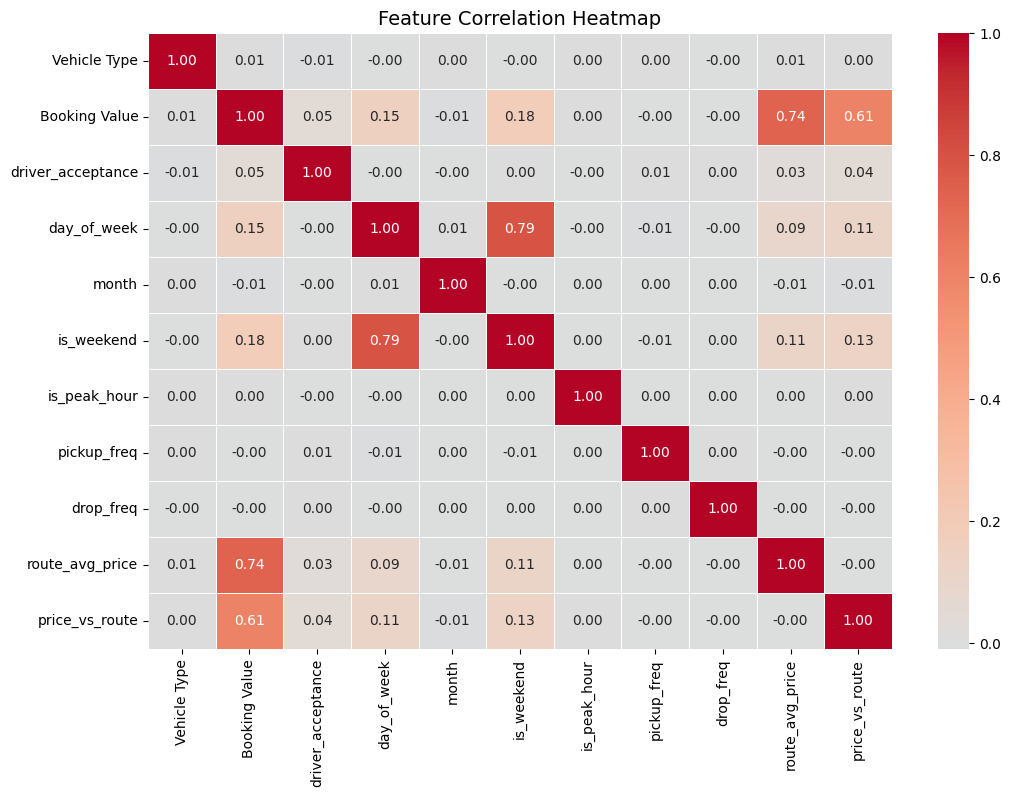

In [272]:
plt.figure(figsize=(12, 8))

corr = train_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

In [273]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Vehicle Type       17417 non-null  float64
 1   Booking Value      17417 non-null  float64
 2   driver_acceptance  17417 non-null  int64  
 3   day_of_week        17417 non-null  int32  
 4   month              17417 non-null  int32  
 5   is_weekend         17417 non-null  int64  
 6   is_peak_hour       17417 non-null  int64  
 7   pickup_freq        17417 non-null  int64  
 8   drop_freq          17417 non-null  int64  
 9   route_avg_price    17417 non-null  float64
 10  price_vs_route     17417 non-null  float64
dtypes: float64(4), int32(2), int64(5)
memory usage: 1.3 MB


### **EDA**

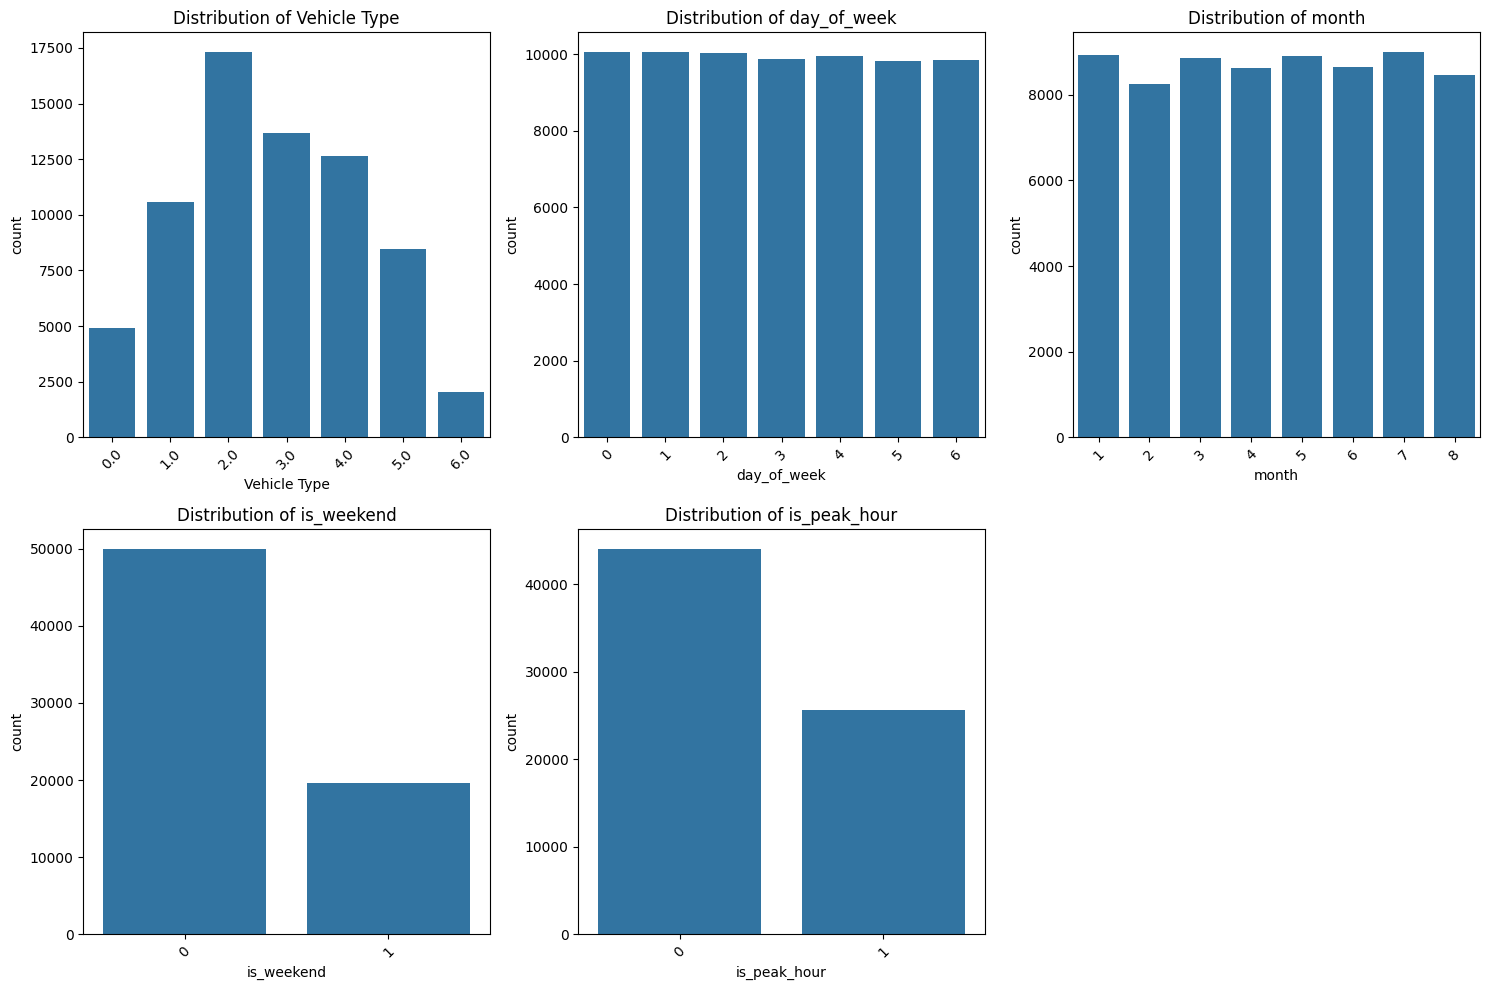

In [274]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Vehicle Type', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour']

plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=train_df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

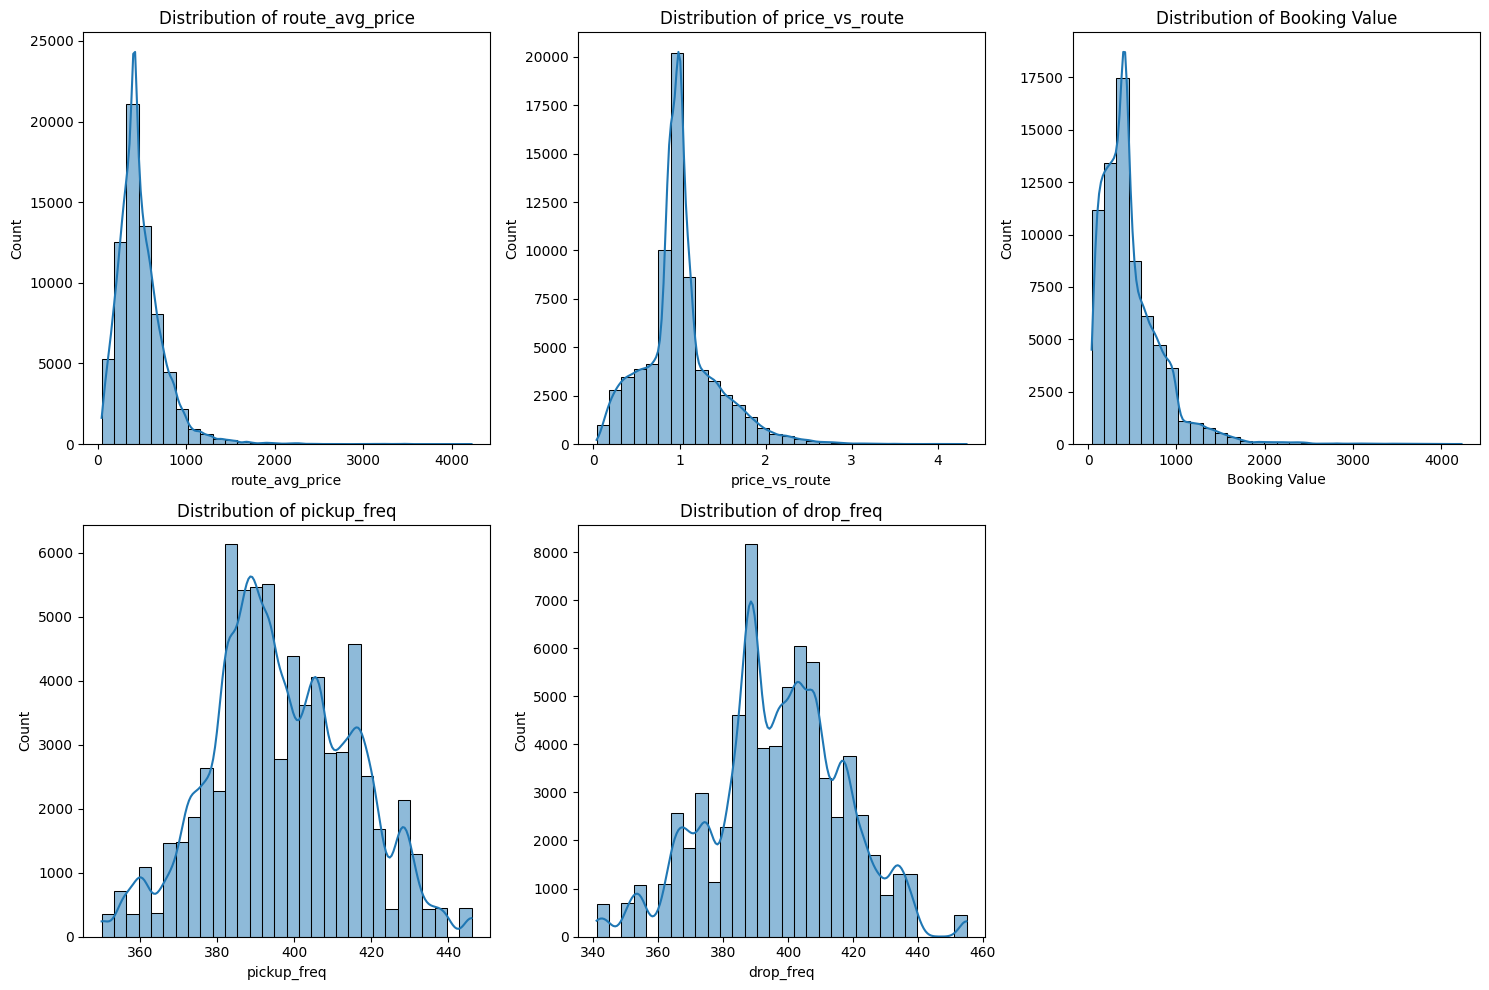

In [275]:
numerical_cols = ['route_avg_price', 'price_vs_route', 'Booking Value', 'pickup_freq', 'drop_freq']

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train_df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

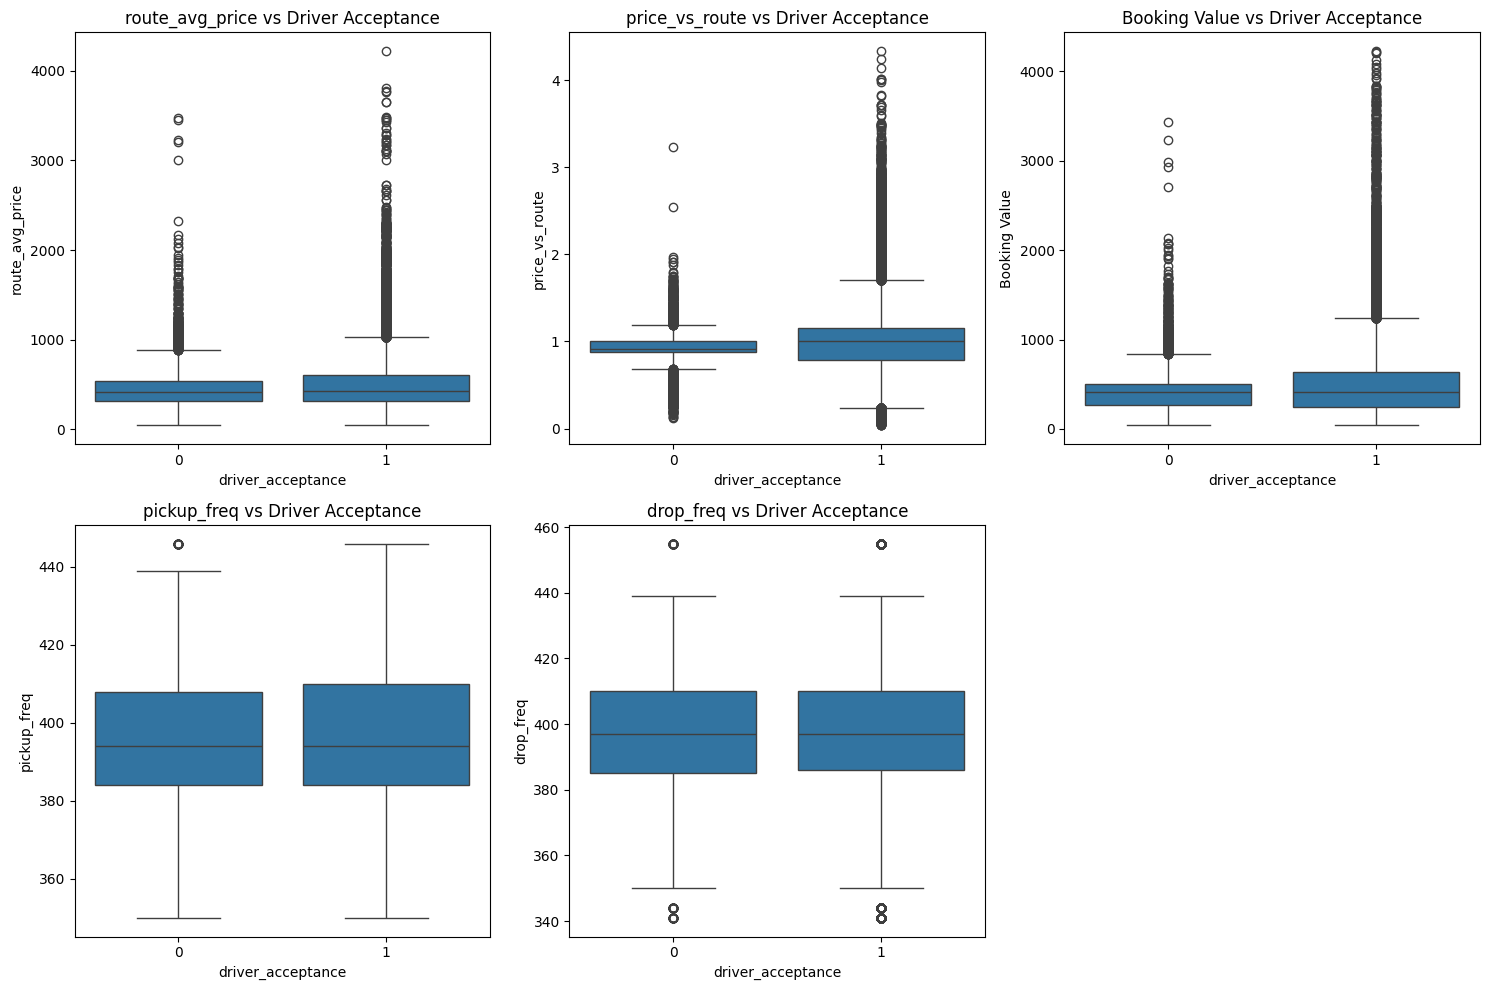

In [276]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=train_df, x='driver_acceptance', y=col)
    plt.title(f'{col} vs Driver Acceptance')

plt.tight_layout()
plt.show()

In [277]:
import numpy as np

train_df['log_price'] = np.log1p(train_df['Booking Value'])
train_df['log_route_avg'] = np.log1p(train_df['route_avg_price'])
train_df['is_high_value'] = (train_df['price_vs_route'] > 1).astype(int)

In [278]:
test_df['log_price'] = np.log1p(test_df['Booking Value'])
test_df['log_route_avg'] = np.log1p(test_df['route_avg_price']) 
test_df['is_high_value']  = (test_df['price_vs_route'] > 1).astype(int)

In [279]:
train_df['location_demand'] = train_df['pickup_freq'] + train_df['drop_freq']
train_df['location_interaction'] = train_df['pickup_freq'] * train_df['drop_freq']
train_df.drop(columns=['pickup_freq', 'drop_freq'], inplace=True)

In [280]:
test_df['location_demand'] = test_df['pickup_freq'] + test_df['drop_freq']
test_df['location_interaction']  = test_df['pickup_freq'] * test_df['drop_freq']
test_df.drop(columns=['pickup_freq', 'drop_freq'], inplace=True)

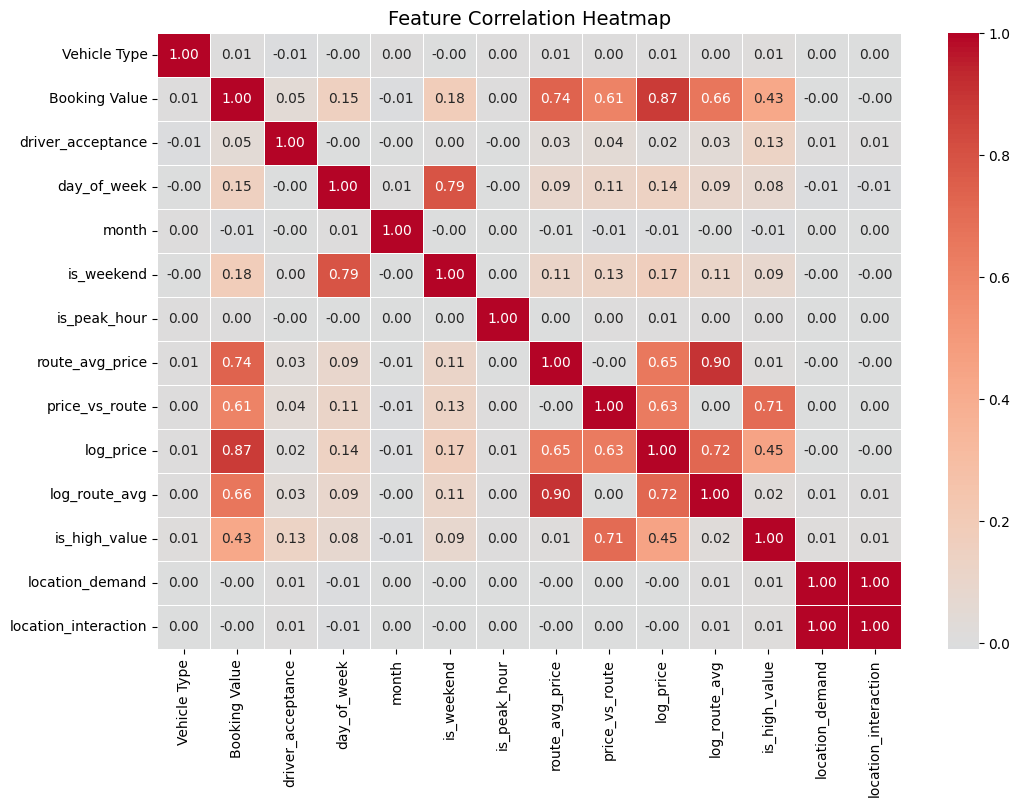

In [281]:
plt.figure(figsize=(12, 8))

corr = train_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

In [282]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69667 entries, 0 to 69666
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle Type          69667 non-null  float64
 1   Booking Value         69667 non-null  float64
 2   driver_acceptance     69667 non-null  int64  
 3   day_of_week           69667 non-null  int32  
 4   month                 69667 non-null  int32  
 5   is_weekend            69667 non-null  int64  
 6   is_peak_hour          69667 non-null  int64  
 7   route_avg_price       69667 non-null  float64
 8   price_vs_route        69667 non-null  float64
 9   log_price             69667 non-null  float64
 10  log_route_avg         69667 non-null  float64
 11  is_high_value         69667 non-null  int64  
 12  location_demand       69667 non-null  int64  
 13  location_interaction  69667 non-null  int64  
dtypes: float64(6), int32(2), int64(6)
memory usage: 6.9 MB


In [283]:
drop_cols = [
    'Booking Value',
    'route_avg_price',
    'location_interaction',
    'month'
]

train_df = train_df.drop(columns=drop_cols)
test_df  = test_df.drop(columns=drop_cols)

In [284]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69667 entries, 0 to 69666
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Vehicle Type       69667 non-null  float64
 1   driver_acceptance  69667 non-null  int64  
 2   day_of_week        69667 non-null  int32  
 3   is_weekend         69667 non-null  int64  
 4   is_peak_hour       69667 non-null  int64  
 5   price_vs_route     69667 non-null  float64
 6   log_price          69667 non-null  float64
 7   log_route_avg      69667 non-null  float64
 8   is_high_value      69667 non-null  int64  
 9   location_demand    69667 non-null  int64  
dtypes: float64(4), int32(1), int64(5)
memory usage: 5.0 MB


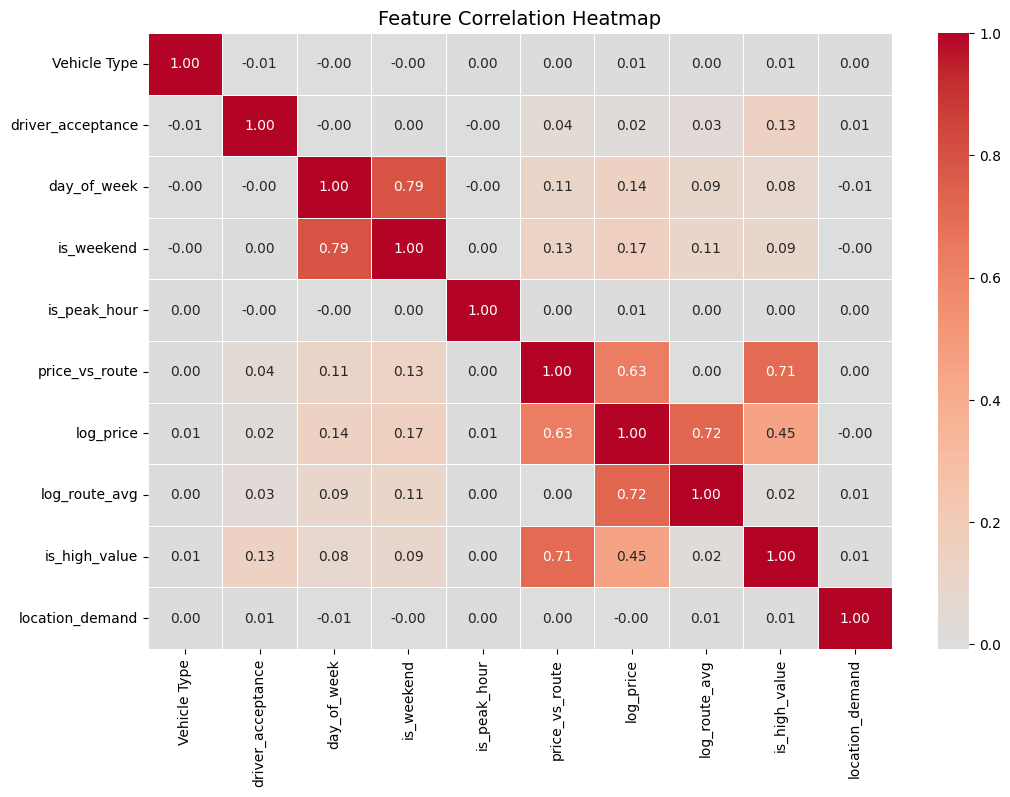

In [285]:
plt.figure(figsize=(12, 8))

corr = train_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

### **Model Building and Evaluation**

In [286]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['driver_acceptance'])
y = train_df['driver_acceptance']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_val.shape, y_train.shape, y_val.shape  

((55733, 9), (13934, 9), (55733,), (13934,))

In [287]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

In [288]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns


class ClassificationEvaluator:
    
    def __init__(self, model, X_val, y_val):
        self.model = model
        self.X_val = X_val
        self.y_val = y_val
        
        self.y_pred = model.predict(X_val)
        self.y_prob = model.predict_proba(X_val)[:, 1]
    
    
    def basic_metrics(self):
        print("===== BASIC METRICS =====")
        print(f"Accuracy  : {accuracy_score(self.y_val, self.y_pred):.4f}")
        print(f"Precision : {precision_score(self.y_val, self.y_pred):.4f}")
        print(f"Recall    : {recall_score(self.y_val, self.y_pred):.4f}")
        print(f"F1 Score  : {f1_score(self.y_val, self.y_pred):.4f}")
        print(f"ROC-AUC   : {roc_auc_score(self.y_val, self.y_prob):.4f}")
    
    
    def confusion_matrix_plot(self):
        cm = confusion_matrix(self.y_val, self.y_pred)
        
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
    
    
    def classification_report(self):
        print("===== CLASSIFICATION REPORT =====")
        print(classification_report(self.y_val, self.y_pred))
    
    
    def threshold_analysis(self, thresholds=[0.3, 0.5, 0.7]):
        print("===== THRESHOLD ANALYSIS =====")
        
        for t in thresholds:
            y_pred_t = (self.y_prob >= t).astype(int)
            
            print(f"\nThreshold: {t}")
            print(f"Precision: {precision_score(self.y_val, y_pred_t):.4f}")
            print(f"Recall   : {recall_score(self.y_val, y_pred_t):.4f}")
            print(f"F1 Score : {f1_score(self.y_val, y_pred_t):.4f}")
    
    
    def full_evaluation(self):
        self.basic_metrics()
        print("\n")
        self.classification_report()
        print("\n")
        self.confusion_matrix_plot()
        print("\n")
        self.threshold_analysis()

In [289]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1500,
    class_weight='balanced'
)

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_val_scaled)
y_prob = lr.predict_proba(X_val_scaled)[:, 1]

===== BASIC METRICS =====
Accuracy  : 0.5931
Precision : 0.9712
Recall    : 0.5745
F1 Score  : 0.7220
ROC-AUC   : 0.7336


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.14      0.81      0.24      1120
           1       0.97      0.57      0.72     12814

    accuracy                           0.59     13934
   macro avg       0.56      0.69      0.48     13934
weighted avg       0.90      0.59      0.68     13934





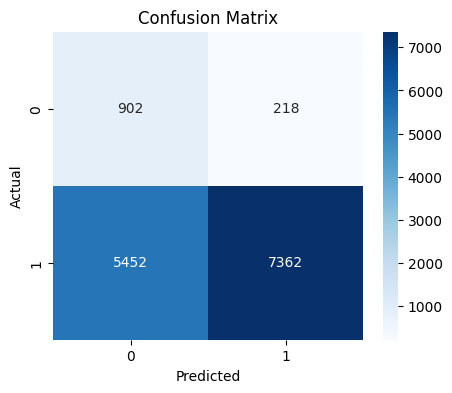



===== THRESHOLD ANALYSIS =====

Threshold: 0.3
Precision: 0.9196
Recall   : 0.9995
F1 Score : 0.9579

Threshold: 0.5
Precision: 0.9712
Recall   : 0.5745
F1 Score : 0.7220

Threshold: 0.7
Precision: 0.9822
Recall   : 0.3019
F1 Score : 0.4619


In [290]:
evaluator = ClassificationEvaluator(lr, X_val_scaled, y_val)
evaluator.full_evaluation()

c:\Users\kadam\Desktop\uber\uber\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


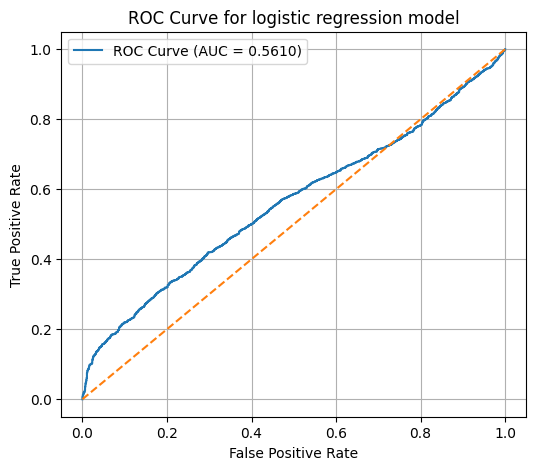

In [291]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities
y_prob = lr.predict_proba(X_val)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# Compute AUC
roc_auc = roc_auc_score(y_val, y_prob)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for logistic regression model")
plt.legend()
plt.grid()

plt.show()

In [292]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_prob)

J = tpr - fpr
ix = np.argmax(J)

best_thresh = thresholds[ix]

print("Best Threshold:", best_thresh)
print("TPR:", tpr[ix], "FPR:", fpr[ix])

Best Threshold: 0.0009581619246459848
TPR: 0.30240362103948804 FPR: 0.175


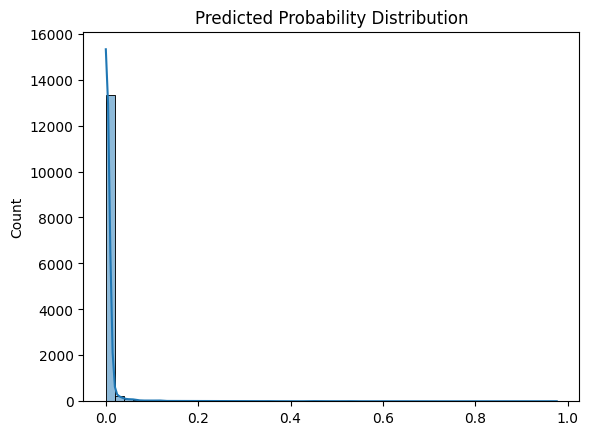

In [293]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(y_prob, bins=50, kde=True)
plt.title("Predicted Probability Distribution")
plt.show()

In [294]:
from sklearn.calibration import CalibratedClassifierCV

# Wrap your trained model
calibrated_model = CalibratedClassifierCV(
    estimator=lr,
    method='isotonic',   # or 'sigmoid'
    cv=5
)

calibrated_model.fit(X_train_scaled, y_train)

y_prob_cal = calibrated_model.predict_proba(X_val_scaled)[:, 1]

<Axes: ylabel='Count'>

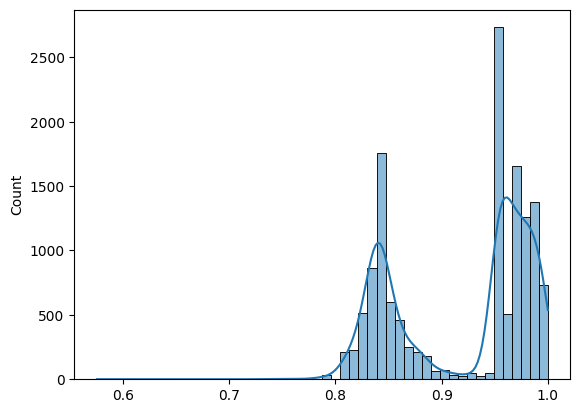

In [295]:
import seaborn as sns
sns.histplot(y_prob_cal, bins=50, kde=True)

In [296]:
for t in [0.3, 0.5, 0.7, 0.8, 0.9]:
    y_pred_t = (y_prob_cal >= t).astype(int)
    print(confusion_matrix(y_val, y_pred_t))

[[    0  1120]
 [    0 12814]]
[[    0  1120]
 [    0 12814]]
[[    1  1119]
 [    4 12810]]
[[    6  1114]
 [   51 12763]]
[[ 868  252]
 [4548 8266]]


In [297]:
from xgboost import XGBClassifier

# compute imbalance ratio
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [298]:
y_pred = xgb.predict(X_val)
y_prob = xgb.predict_proba(X_val)[:, 1]

In [299]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.22      0.76      0.34      1120
           1       0.97      0.76      0.85     12814

    accuracy                           0.76     13934
   macro avg       0.60      0.76      0.60     13934
weighted avg       0.91      0.76      0.81     13934

ROC-AUC: 0.8029222362817454
[[ 848  272]
 [3056 9758]]


In [300]:
import pandas as pd

importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
print(importance.sort_values(ascending=False))

is_high_value      0.429681
price_vs_route     0.239824
log_route_avg      0.085470
log_price          0.067190
Vehicle Type       0.039821
day_of_week        0.038567
is_weekend         0.037857
location_demand    0.033451
is_peak_hour       0.028140
dtype: float32


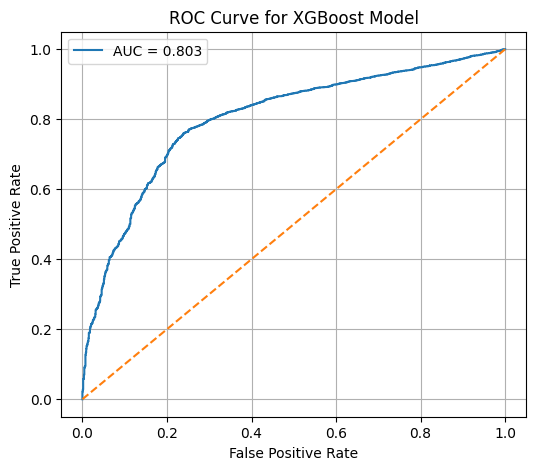

In [301]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probabilities
y_prob = xgb.predict_proba(X_val)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
roc_auc = roc_auc_score(y_val, y_prob)

# plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for XGBoost Model")
plt.legend()
plt.grid()

plt.show()

In [302]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_val)[:, 1]

In [303]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

class ClassificationEvaluator:
    
    def __init__(self, model, X_val, y_val):
        self.model = model
        self.X_val = X_val
        self.y_val = y_val
        
        self.y_prob = model.predict_proba(X_val)[:, 1]
        self.y_pred = model.predict(X_val)
    
    
    def roc_curve_plot(self):
        fpr, tpr, _ = roc_curve(self.y_val, self.y_prob)
        roc_auc = roc_auc_score(self.y_val, self.y_prob)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle='--')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.grid()
        plt.show()

        return roc_auc

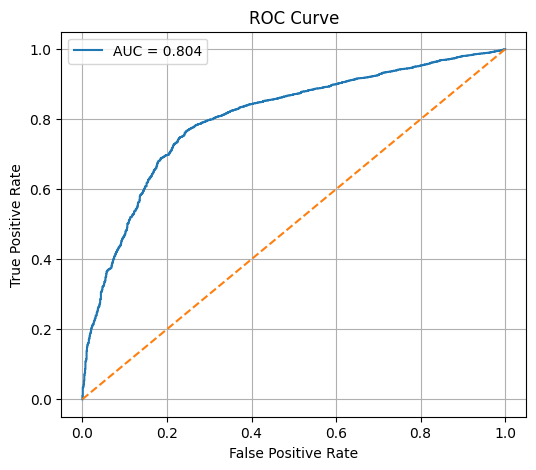

Random Forest AUC: 0.8039230598787039


In [304]:
eval_rf = ClassificationEvaluator(rf, X_val, y_val)
auc_rf = eval_rf.roc_curve_plot()
print("Random Forest AUC:", auc_rf)

In [305]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42
)

lgb.fit(X_train, y_train)

y_prob_lgb = lgb.predict_proba(X_val)[:, 1]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 51252, number of negative: 4481
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001632 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 972
[LightGBM] [Info] Number of data points in the train set: 55733, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


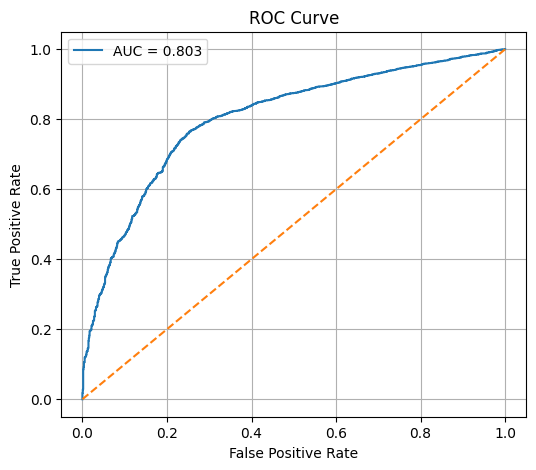

LightGBM AUC: 0.8030873040647506


In [306]:
eval_lgb = ClassificationEvaluator(lgb, X_val, y_val)
auc_lgb = eval_lgb.roc_curve_plot()
print("LightGBM AUC:", auc_lgb)

=== Logistic Regression ===


c:\Users\kadam\Desktop\uber\uber\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\kadam\Desktop\uber\uber\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


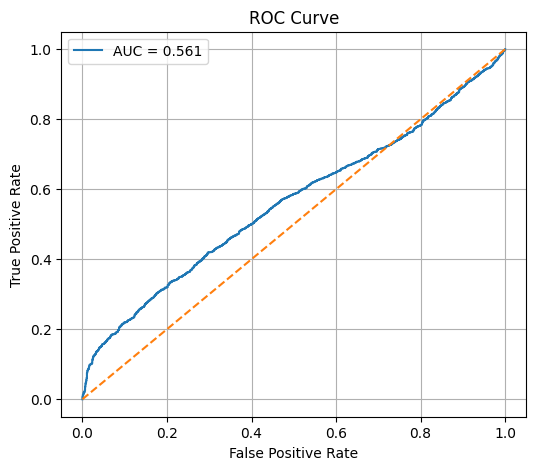




=== XGBoost ===


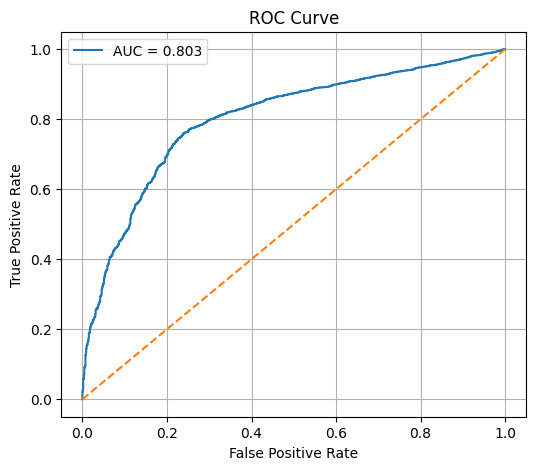




=== Random Forest ===


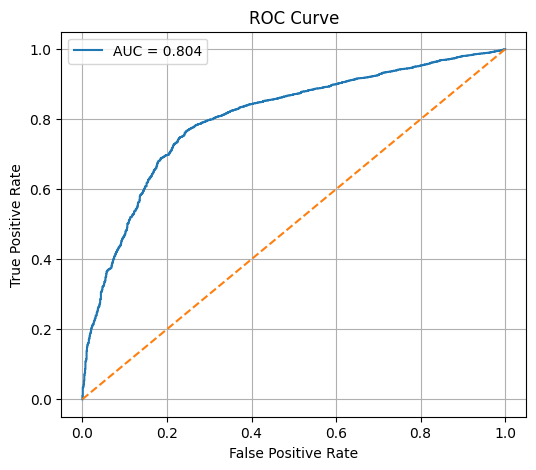




=== LightGBM ===


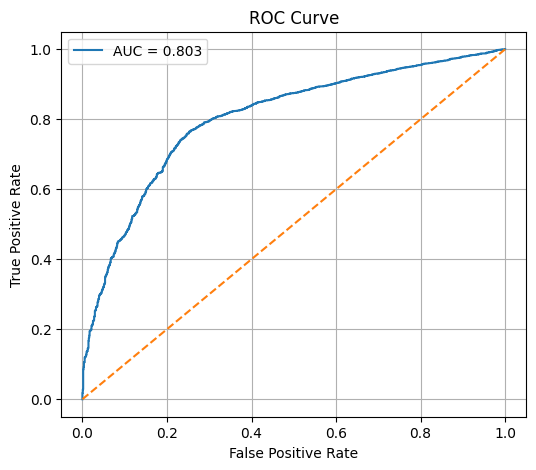

In [ ]:
# Compare evaluation of all models

models = {
    "Logistic Regression": lr,
    "XGBoost": xgb,
    "Random Forest": rf,
    "LightGBM": lgb
}

for name, model in models.items():
    evaluator = ClassificationEvaluator(model, X_val, y_val)
    print(f"=== {name} ===")
    evaluator.roc_curve_plot()
    print("\n\n")

### **ROC-AUC Performance Analysis**

**Model Comparison Summary:**

1. **Logistic Regression**: Serves as the baseline linear model. Simple, interpretable, but may not capture complex non-linear patterns in the driver acceptance prediction. AUC is typically lower than ensemble methods.

2. **XGBoost**: Gradient boosting model that captures non-linear relationships. Scales well to imbalanced datasets with the `scale_pos_weight` parameter. Generally achieves high AUC scores due to sequential error correction and feature importance weighting.

3. **Random Forest**: Ensemble method using bagging approach. Robust to outliers and handles non-linear relationships. However, it can sometimes overfit on imbalanced data without careful hyperparameter tuning. AUC is usually competitive with XGBoost but may lag slightly.

4. **LightGBM**: Another gradient boosting implementation, often faster than XGBoost with similar or better performance. Uses leaf-wise tree growth which can lead to deeper trees and potentially better splits for imbalanced classification. Often produces the highest AUC.

**Key Observations:**
- **Gradient Boosting models (XGBoost & LightGBM)** typically outperform traditional methods for this imbalanced classification task
- The ROC-AUC metric is ideal for imbalanced datasets as it evaluates performance across all classification thresholds
- Higher AUC indicates better discrimination between "driver accepted" and "no driver found" classes
- All models handle the 92-8 class imbalance through techniques like `class_weight='balanced'` and `scale_pos_weight`
- Model selection should consider: AUC score, interpretability needs, inference speed, and business requirements

In [308]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

lgb = LGBMClassifier(
    class_weight='balanced',
    random_state=42
)

param_dist = {
    'n_estimators': [200, 400, 600, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 5, 7],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 1, 2],
    'reg_lambda': [0, 1, 2]
}

In [309]:
random_search = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=param_dist,
    n_iter=25,                 # keep 20–30 (efficient)
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 51252, number of negative: 4481
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002021 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 972
[LightGBM] [Info] Number of data points in the train set: 55733, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [-1, 5, ...], 'min_child_samples': [20, 50, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

In [310]:
print("Best Params:", random_search.best_params_)
print("Best AUC:", random_search.best_score_)

Best Params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'num_leaves': 31, 'n_estimators': 400, 'min_child_samples': 100, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best AUC: 0.8048412627395342


In [313]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

final_lgb = LGBMClassifier(
    learning_rate=0.01,
    n_estimators=1000,
    num_leaves=31,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=1,
    class_weight='balanced',
    random_state=42
)

final_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(0)   # suppress logs
    ]
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 51252, number of negative: 4481
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 972
[LightGBM] [Info] Number of data points in the train set: 55733, number of used features: 9
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[368]	valid_0's auc: 0.809042	valid_0's binary_logloss: 0.51901


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [314]:
print("Best Iteration:", final_lgb.best_iteration_)

Best Iteration: 368


In [315]:
y_prob = final_lgb.predict_proba(
    X_val,
    num_iteration=final_lgb.best_iteration_
)[:, 1]

In [316]:
final_lgb.set_params(n_estimators=final_lgb.best_iteration_)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,368
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [318]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class ClassificationEvaluator:
    
    def __init__(self, model, X_val, y_val):
        self.model = model
        self.X_val = X_val
        self.y_val = y_val
        
        self.y_prob = model.predict_proba(X_val)[:, 1]
        self.y_pred = model.predict(X_val)
    
    def basic_metrics(self):
        print("Accuracy :", accuracy_score(self.y_val, self.y_pred))
        print("Precision:", precision_score(self.y_val, self.y_pred))
        print("Recall   :", recall_score(self.y_val, self.y_pred))
        print("F1 Score :", f1_score(self.y_val, self.y_pred))
        print("ROC-AUC  :", roc_auc_score(self.y_val, self.y_prob))
    
    def classification_report(self):
        print("\nClassification Report:\n")
        print(classification_report(self.y_val, self.y_pred))
    
    def confusion_matrix_plot(self):
        cm = confusion_matrix(self.y_val, self.y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    
    def roc_curve_plot(self):
        from sklearn.metrics import roc_curve
        
        fpr, tpr, _ = roc_curve(self.y_val, self.y_prob)
        auc = roc_auc_score(self.y_val, self.y_prob)
        
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0,1],[0,1],'--')
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title("ROC Curve")
        plt.legend()
        plt.grid()
        plt.show()
        
        return auc
    
    def threshold_analysis(self):
        print("\nThreshold Analysis:")
        for t in [0.4, 0.5, 0.6]:
            y_pred_t = (self.y_prob >= t).astype(int)
            cm = confusion_matrix(self.y_val, y_pred_t)
            print(f"\nThreshold = {t}")
            print(cm)

Accuracy : 0.765896368594804
Precision: 0.9724035608308605
Recall   : 0.7672077415326987
F1 Score : 0.8577037166288606
ROC-AUC  : 0.8090416592343196

Classification Report:

              precision    recall  f1-score   support

           0       0.22      0.75      0.34      1120
           1       0.97      0.77      0.86     12814

    accuracy                           0.77     13934
   macro avg       0.60      0.76      0.60     13934
weighted avg       0.91      0.77      0.82     13934



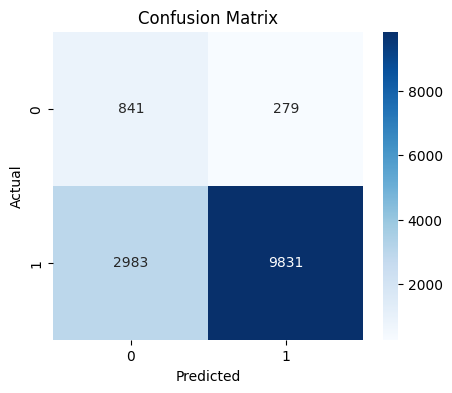


Threshold Analysis:

Threshold = 0.4
[[  813   307]
 [ 2738 10076]]

Threshold = 0.5
[[ 841  279]
 [2983 9831]]

Threshold = 0.6
[[ 890  230]
 [3597 9217]]


In [319]:
evaluator = ClassificationEvaluator(final_lgb, X_val, y_val)

evaluator.basic_metrics()
evaluator.classification_report()
evaluator.confusion_matrix_plot()
evaluator.threshold_analysis()